In [1]:
import os
import math
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler


output_dir = "../results/xgb_feature_importance_plots"
os.makedirs(output_dir, exist_ok=True)

top_n = 10
n_runs = 100


# 1. tuned XGBoost parameters for period-specific models

# Model 1a: face mask behaviour before mandates
params_1a = {
    "colsample_bytree": 1.0,
    "learning_rate": 0.1,
    "max_depth": 7,
    "subsample": 0.8
}

# Model 1b: face mask behaviour after mandates
params_1b = {
    "colsample_bytree": 1.0,
    "learning_rate": 0.1,
    "max_depth": 7,
    "subsample": 0.8
}

# Model 2a: general protective behaviour before mandates
params_2a = {
    "colsample_bytree": 1.0,
    "learning_rate": 0.05,
    "max_depth": 7,
    "subsample": 0.8
}

# Model 2b: general protective behaviour after mandates
params_2b = {
    "colsample_bytree": 1.0,
    "learning_rate": 0.1,
    "max_depth": 7,
    "subsample": 0.8
}

In [2]:
# 2. Feature labels and feature groups

def clean_category_name(x):
    # clean dummy variable category names for plotting

    x = str(x).replace("_", " ").strip()

    special_words = {
        "N/A": "N/A",
        "NA": "N/A",
        "COVID": "COVID",
        "COVID-19": "COVID-19",
        "NHS": "NHS",
        "UK": "UK"
    }

    lower_words = {"to", "in", "if", "of", "or", "and", "for", "nor", "not", "say"}

    cleaned_words = []

    for word in x.split():
        upper_word = word.upper()

        if upper_word in special_words:
            cleaned_words.append(special_words[upper_word])
        elif word.lower() in lower_words:
            cleaned_words.append(word.lower())
        else:
            cleaned_words.append(word.capitalize())

    return " ".join(cleaned_words)


# Labels used on the y-axis of the feature importance plots
FEATURE_LABELS = {
    # Time
    "qweek": "Week Number",
    "week_number": "Week Number",
    "survey_week": "Week Number",

    # Demographics
    "age": "Age",
    "gender": "Gender",
    "household_size": "Household Size",
    "employment_status": "Employment Status",

    # Contact / mobility
    "i1_health": "Household Contacts",
    "i2_health": "Non-Household Contacts",
    "i7a_health": "Times Left Home",

    # COVID test / health status
    "i3_health": "Personal COVID Test",
    "i4_health": "Household COVID Test",
    "d1_comorbidities": "Comorbidities",

    # Isolation-related variables
    "i9_health": "Isolate If Unwell",
    "i10_health": "Feasibility To Isolate",
    "i11_health": "Willing To Isolate",

    # Perception of illness threat
    "r1_1": "Perceived Severity",
    "r1_2": "Perceived Susceptibility",

    # Trust in government
    "WCRex1": "Government Handling",
    "WCRex2": "Confidence in Response",

    # Worry / feeling towards COVID
    "WCRV_4": "Worrying",

    # Wellbeing and mental health
    "cantril_ladder": "Cantril Ladder",
    "PHQ4_1": "Little Interest or Pleasure",
    "PHQ4_2": "Feeling Down or Depressed",
    "PHQ4_3": "Feeling Nervous or Anxious",
    "PHQ4_4": "Unable To Stop Worrying",

    # Aggregated protective behaviour features
    "protective_behaviour": "Self Protective Behaviours",
    "protective_behaviour_scale": "Self Protective Behaviours",
    "protective_health_behaviour": "Self Protective Behaviours",
    "protective_health_behaviour_scale": "Self Protective Behaviours",
    "general_protective_behaviour": "Self Protective Behaviours",
    "general_protective_behaviour_scale": "Self Protective Behaviours",
    "other_protective_behaviour": "Self Protective Behaviours",
    "other_protective_behaviour_scale": "Self Protective Behaviours",
    "non_mask_protective_behaviour": "Self Protective Behaviours",
    "non_mask_protective_behaviour_scale": "Self Protective Behaviours",
    "protective_behaviour_nomask_scale": "Self Protective Behaviours",
}


def readable_feature_name(feature):
    # convert original feature names into readable labels
    # keep dummy variable categories together with their original variable
    feature = str(feature)

    # exact match for continuous or aggregated features
    if feature in FEATURE_LABELS:
        return FEATURE_LABELS[feature]

    # match dummy variables
    # sorting by length avoids matching i1_health before i11_health
    for var_code in sorted(FEATURE_LABELS.keys(), key=len, reverse=True):
        prefix = var_code + "_"

        if feature.startswith(prefix):
            variable_label = FEATURE_LABELS[var_code]
            response_category = feature.replace(prefix, "", 1)
            response_category = clean_category_name(response_category)

            return f"{variable_label} ({response_category})"

    # handle state variables if they are present
    if feature.startswith("state_"):
        state_name = feature.replace("state_", "", 1)
        return f"State ({clean_category_name(state_name)})"

    # fallback for variables not listed above
    return clean_category_name(feature)


def wrap_labels(labels, width=28):
    # wrap long feature labels to improve readability
    return [
        "\n".join(textwrap.wrap(str(label), width=width))
        for label in labels
    ]


# Groups used to colour the bars
FEATURE_GROUPS = {
    # Time
    "qweek": "Time",
    "week_number": "Time",
    "survey_week": "Time",

    # Self-protective behaviours
    "i1_health": "Self-protective behaviours",
    "i2_health": "Self-protective behaviours",
    "i7a_health": "Self-protective behaviours",
    "i9_health": "Self-protective behaviours",
    "i10_health": "Self-protective behaviours",
    "i11_health": "Self-protective behaviours",

    "protective_behaviour": "Self-protective behaviours",
    "protective_behaviour_scale": "Self-protective behaviours",
    "protective_health_behaviour": "Self-protective behaviours",
    "protective_health_behaviour_scale": "Self-protective behaviours",
    "general_protective_behaviour": "Self-protective behaviours",
    "general_protective_behaviour_scale": "Self-protective behaviours",
    "other_protective_behaviour": "Self-protective behaviours",
    "other_protective_behaviour_scale": "Self-protective behaviours",
    "non_mask_protective_behaviour": "Self-protective behaviours",
    "non_mask_protective_behaviour_scale": "Self-protective behaviours",
    "protective_behaviour_nomask_scale": "Self-protective behaviours",

    # Demographics
    "age": "Demographics",
    "gender": "Demographics",
    "household_size": "Demographics",
    "employment_status": "Demographics",
    "state": "Demographics",

    # Trust in government
    "WCRex1": "Trust in government",
    "WCRex2": "Trust in government",

    # Health, mental health and wellbeing
    "d1_comorbidities": "Health, mental health and wellbeing",
    "cantril_ladder": "Health, mental health and wellbeing",
    "PHQ4_1": "Health, mental health and wellbeing",
    "PHQ4_2": "Health, mental health and wellbeing",
    "PHQ4_3": "Health, mental health and wellbeing",
    "PHQ4_4": "Health, mental health and wellbeing",

    # Perception of illness threat
    "r1_1": "Perception of illness threat",
    "r1_2": "Perception of illness threat",
    "WCRV_4": "Perception of illness threat",
}


def get_feature_group(feature):
    # assign each raw feature to a broader feature group
    feature = str(feature)

    # exact match
    if feature in FEATURE_GROUPS:
        return FEATURE_GROUPS[feature]

    # match dummy variables
    for var_code in sorted(FEATURE_GROUPS.keys(), key=len, reverse=True):
        prefix = var_code + "_"

        if feature.startswith(prefix):
            return FEATURE_GROUPS[var_code]

    # handle state variables if they are present
    if feature.startswith("state_"):
        return "Demographics"

    return "Other"

# Colours were selected with AI assistance to make the feature groups visually distinct
GROUP_COLORS = {
    "Self-protective behaviours": "#1f77b4",
    "Demographics": "#2ca02c",
    "Health, mental health and wellbeing": "#9467bd",
    "Perception of illness threat": "#d62728",
    "Time": "#ffbf00",
    "Trust in government": "#8c564b",
    "Other": "#999999"
}

In [3]:
# 3. Repeated XGBoost fitting and feature importance extraction

def get_xgb_importance(x_train_path, y_train_path, model_params, n_runs=100, upsample=True):
    # fit XGBoost repeatedly and summarise feature importance
    X_train = pd.read_csv(x_train_path)
    y_train = pd.read_csv(y_train_path)["y"]

    all_importances = []

    for seed in range(n_runs):
        X_fit = X_train.copy()
        y_fit = y_train.copy()

        # apply random over-sampling with a different seed in each run
        if upsample:
            upsampler = RandomOverSampler(random_state=seed)
            X_fit, y_fit = upsampler.fit_resample(X_fit, y_fit)

        model = XGBClassifier(
            n_estimators=250,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=seed,
            **model_params
        )

        model.fit(X_fit, y_fit)

        temp_df = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": model.feature_importances_,
            "Run": seed
        })

        all_importances.append(temp_df)

    importance_all = pd.concat(all_importances, ignore_index=True)

    # use the median as the central estimate and Q1/Q3 as variability
    importance_df = (
        importance_all
        .groupby("Feature")["Importance"]
        .agg(
            Importance="median",
            Q1=lambda x: np.percentile(x, 25),
            Q3=lambda x: np.percentile(x, 75)
        )
        .reset_index()
        .sort_values(by="Importance", ascending=False)
        .reset_index(drop=True)
    )

    return importance_df

def remove_state_features(importance_df):
    # remove state dummy variables after feature importance has been calculated
    return importance_df.loc[
        ~importance_df["Feature"].str.lower().str.contains("state")
    ].copy()

In [4]:
# 4. Prepare before-after comparison table

def prepare_before_after_df(before_df, after_df, top_n_each=10):
    # select the union of the top features before and after mandates
    before_top = before_df.head(top_n_each)[["Feature", "Importance", "Q1", "Q3"]].copy()
    before_top = before_top.rename(columns={
        "Importance": "Before",
        "Q1": "Before_Q1",
        "Q3": "Before_Q3"
    })
    after_top = after_df.head(top_n_each)[["Feature", "Importance", "Q1", "Q3"]].copy()
    after_top = after_top.rename(columns={
        "Importance": "After",
        "Q1": "After_Q1",
        "Q3": "After_Q3"
    })

    # keep features that appear in either top-N list
    merged = pd.merge(before_top, after_top, on="Feature", how="outer")

    # features absent from one period receive zero importance for that side
    for col in ["Before", "Before_Q1", "Before_Q3", "After", "After_Q1", "After_Q3"]:
        merged[col] = merged[col].fillna(0)

    # used only for ordering the plot
    merged["Total"] = merged["Before"].abs() + merged["After"].abs()
    merged["Feature_raw"] = merged["Feature"]
    merged["Group"] = merged["Feature_raw"].apply(get_feature_group)
    merged["Feature"] = merged["Feature_raw"].apply(readable_feature_name)

    # plot before-mandate importance on the left side for visual comparison
    merged["Before"] = -merged["Before"]
    merged["Before_Q1"] = -merged["Before_Q1"]
    merged["Before_Q3"] = -merged["Before_Q3"]

    # sort so larger total importance appears higher in the final figure
    merged = merged.sort_values("Total", ascending=True).reset_index(drop=True)

    return merged

In [22]:
# 5. Plot before-after feature importance comparison

def plot_before_after(plot_df, save_path):
    # plot median feature importance with interquartile range error bars
    plt.figure(figsize=(14, 10))

    axis_label_size = 16
    tick_label_size = 16
    legend_size = 16

    y_pos = np.arange(len(plot_df))

    bar_colors = plot_df["Group"].map(GROUP_COLORS).fillna("#999999")

    # error bars for before mandates; values are shown on the left side for visual comparison
    before_left_error = (plot_df["Before"] - plot_df["Before_Q3"]).abs()
    before_right_error = (plot_df["Before_Q1"] - plot_df["Before"]).abs()
    before_xerr = np.vstack([before_left_error, before_right_error])

    # error bars for after mandates
    after_left_error = (plot_df["After"] - plot_df["After_Q1"]).abs()
    after_right_error = (plot_df["After_Q3"] - plot_df["After"]).abs()
    after_xerr = np.vstack([after_left_error, after_right_error])

    plt.barh(
        y_pos,
        plot_df["Before"],
        color=bar_colors,
        xerr=before_xerr,
        error_kw={
            "ecolor": "black",
            "elinewidth": 1.2,
            "capsize": 3
        }
    )

    plt.barh(
        y_pos,
        plot_df["After"],
        color=bar_colors,
        xerr=after_xerr,
        error_kw={
            "ecolor": "black",
            "elinewidth": 1.2,
            "capsize": 3
        }
    )

    plt.axvline(0, color="black", linewidth=1.2)

    plt.yticks(
        y_pos,
        wrap_labels(plot_df["Feature"], width=30),
        fontsize=tick_label_size
    )

    plt.xlabel("Median feature importance", fontsize=axis_label_size)

    max_value = max(
        plot_df["Before"].abs().max(),
        plot_df["After"].abs().max(),
        plot_df["Before_Q1"].abs().max(),
        plot_df["Before_Q3"].abs().max(),
        plot_df["After_Q1"].abs().max(),
        plot_df["After_Q3"].abs().max()
    )

    if max_value == 0:
        axis_limit = 0.05
    else:
        axis_limit = math.ceil(max_value * 1.35 / 0.05) * 0.05

    plt.xlim(-axis_limit, axis_limit)

    ticks = np.arange(-axis_limit, axis_limit + 0.0001, 0.05)
    tick_labels = [f"{abs(t):.2f}" for t in ticks]
    plt.xticks(ticks, tick_labels, fontsize=tick_label_size)

    legend_order = [
        "Self-protective behaviours",
        "Demographics",
        "Health, mental health and wellbeing",
        "Perception of illness threat",
        "Time",
        "Trust in government"
    ]

    handles = []
    for group in legend_order:
        if group in plot_df["Group"].unique():
            handles.append(
                Patch(facecolor=GROUP_COLORS[group], label=group)
            )

    if "Other" in plot_df["Group"].unique():
        handles.append(
            Patch(facecolor=GROUP_COLORS["Other"], label="Other")
        )

    plt.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.13),
        ncol=3,
        frameon=False,
        fontsize=legend_size
    )

    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [6]:
# 6. Print top 10 results

def print_top_features(importance_df, title, top_n=10):
    print(f"\n{title}")
    print(
        importance_df
        .head(top_n)[["Feature", "Importance"]]
        .to_string(index=False)
    )

In [7]:
# 7. Run feature importance analysis and save outputs
# 7.1 Model 1: face mask behaviour

importance_1a = get_xgb_importance(
    x_train_path="../data/model_inputs/X_train_model_1a.csv",
    y_train_path="../data/model_inputs/y_train_model_1a.csv",
    model_params=params_1a,
    n_runs=n_runs,
    upsample=True
)

importance_1b = get_xgb_importance(
    x_train_path="../data/model_inputs/X_train_model_1b.csv",
    y_train_path="../data/model_inputs/y_train_model_1b.csv",
    model_params=params_1b,
    n_runs=n_runs,
    upsample=True
)

In [8]:
# Print top 10 features before removing state variables
print_top_features(
    importance_df=importance_1a,
    title="Model 1a top 10 features with state variables",
    top_n=top_n
)

print_top_features(
    importance_df=importance_1b,
    title="Model 1b top 10 features with state variables",
    top_n=top_n
)


Model 1a top 10 features with state variables
                           Feature  Importance
             state_New South Wales    0.106323
 protective_behaviour_nomask_scale    0.090058
                    state_Tasmania    0.029094
     employment_status_Not working    0.020138
                       week_number    0.019365
d1_comorbidities_Prefer_not_to_say    0.018249
                              r1_1    0.018146
                               age    0.017618
              d1_comorbidities_Yes    0.017536
           i11_health_Very willing    0.017500

Model 1b top 10 features with state variables
                          Feature  Importance
          state_Western Australia    0.126516
                 state_Queensland    0.083030
protective_behaviour_nomask_scale    0.081698
                   state_Tasmania    0.058358
                      week_number    0.027998
          i11_health_Very willing    0.027856
        i11_health_Very unwilling    0.016396
            state_Sou


Model 1a top 10 features without state variables
                           Feature  Importance
 protective_behaviour_nomask_scale    0.090058
     employment_status_Not working    0.020138
                       week_number    0.019365
d1_comorbidities_Prefer_not_to_say    0.018249
                              r1_1    0.018146
                               age    0.017618
              d1_comorbidities_Yes    0.017536
           i11_health_Very willing    0.017500
                i9_health_Not sure    0.016240
                              r1_2    0.015342

Model 1b top 10 features without state variables
                          Feature  Importance
protective_behaviour_nomask_scale    0.081698
                      week_number    0.027998
          i11_health_Very willing    0.027856
        i11_health_Very unwilling    0.016396
                    i9_health_Yes    0.015017
        employment_status_Retired    0.014167
                       PHQ4_2_N/A    0.013839
      WCRex2_No

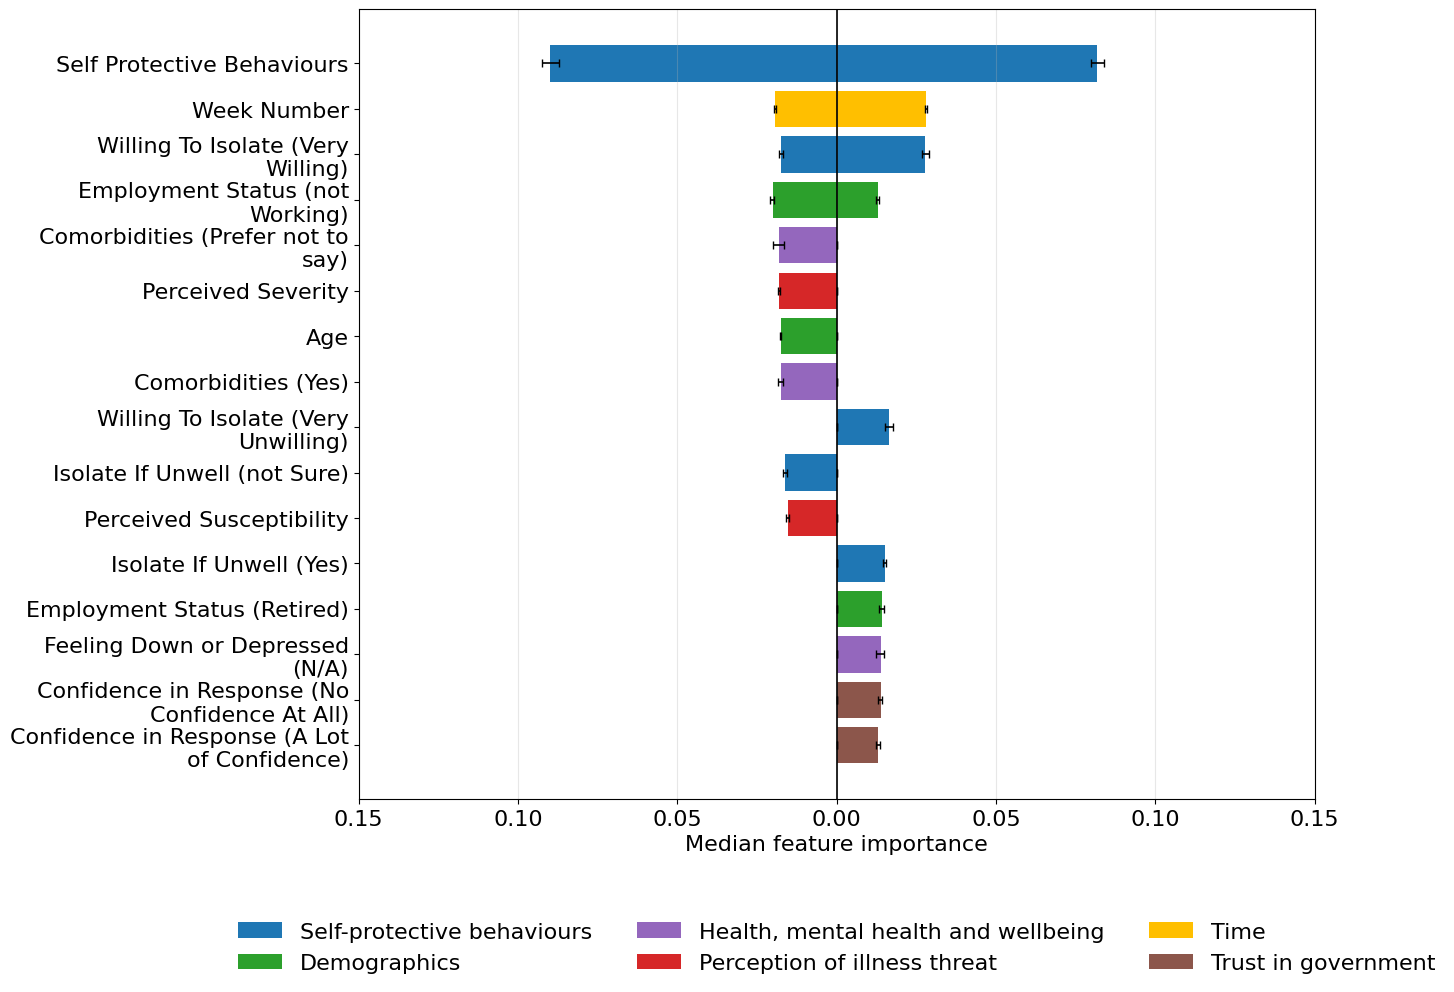

In [23]:
# Remove state variables for final visualisation
importance_1a_no_state = remove_state_features(importance_1a)
importance_1b_no_state = remove_state_features(importance_1b)

# Print top 10 features after removing state variables
print_top_features(
    importance_df=importance_1a_no_state,
    title="Model 1a top 10 features without state variables",
    top_n=top_n
)

print_top_features(
    importance_df=importance_1b_no_state,
    title="Model 1b top 10 features without state variables",
    top_n=top_n
)


# Prepare before-after comparison using non-state features
plot_df_1 = prepare_before_after_df(
    before_df=importance_1a_no_state,
    after_df=importance_1b_no_state,
    top_n_each=top_n
)

plot_df_1.to_csv(
    f"{output_dir}/xgb_model1_feature_importance_readable.csv",
    index=False
)

plot_before_after(
    plot_df=plot_df_1,
    save_path=f"{output_dir}/xgb_model1_before_after.png"
)

In [10]:
# 7.2 Model 2: general protective behaviour

importance_2a = get_xgb_importance(
    x_train_path="../data/model_inputs/X_train_model_2a.csv",
    y_train_path="../data/model_inputs/y_train_model_2a.csv",
    model_params=params_2a,
    n_runs=n_runs,
    upsample=True
)

importance_2b = get_xgb_importance(
    x_train_path="../data/model_inputs/X_train_model_2b.csv",
    y_train_path="../data/model_inputs/y_train_model_2b.csv",
    model_params=params_2b,
    n_runs=n_runs,
    upsample=True
)

In [11]:
# Print top 10 features before removing state variables
print_top_features(
    importance_df=importance_2a,
    title="Model 2a top 10 features with state variables",
    top_n=top_n
)

print_top_features(
    importance_df=importance_2b,
    title="Model 2b top 10 features with state variables",
    top_n=top_n
)


Model 2a top 10 features with state variables
                Feature  Importance
  state_New South Wales    0.038497
              i2_health    0.037058
                   r1_1    0.035842
         state_Victoria    0.034108
          i9_health_Yes    0.027842
     i9_health_Not sure    0.024736
i11_health_Very willing    0.023927
state_Western Australia    0.023430
             PHQ4_2_N/A    0.020294
    i11_health_Not sure    0.019966

Model 2b top 10 features with state variables
                Feature  Importance
state_Western Australia    0.075513
i11_health_Very willing    0.068315
       state_Queensland    0.058345
          i9_health_Yes    0.029090
                   r1_1    0.028107
  state_New South Wales    0.027977
         state_Tasmania    0.027213
              i2_health    0.025415
            week_number    0.023937
         state_Victoria    0.023721



Model 2a top 10 features without state variables
                      Feature  Importance
                    i2_health    0.037058
                         r1_1    0.035842
                i9_health_Yes    0.027842
           i9_health_Not sure    0.024736
      i11_health_Very willing    0.023927
                   PHQ4_2_N/A    0.020294
          i11_health_Not sure    0.019966
                   PHQ4_3_N/A    0.019122
i11_health_Somewhat unwilling    0.019112
    i11_health_Very unwilling    0.018827

Model 2b top 10 features without state variables
                    Feature  Importance
    i11_health_Very willing    0.068315
              i9_health_Yes    0.029090
                       r1_1    0.028107
                  i2_health    0.025415
                week_number    0.023937
         i9_health_Not sure    0.020865
  i11_health_Very unwilling    0.018709
i11_health_Somewhat willing    0.016550
                 PHQ4_2_N/A    0.015175
   PHQ4_4_Prefer not to say    0.01458

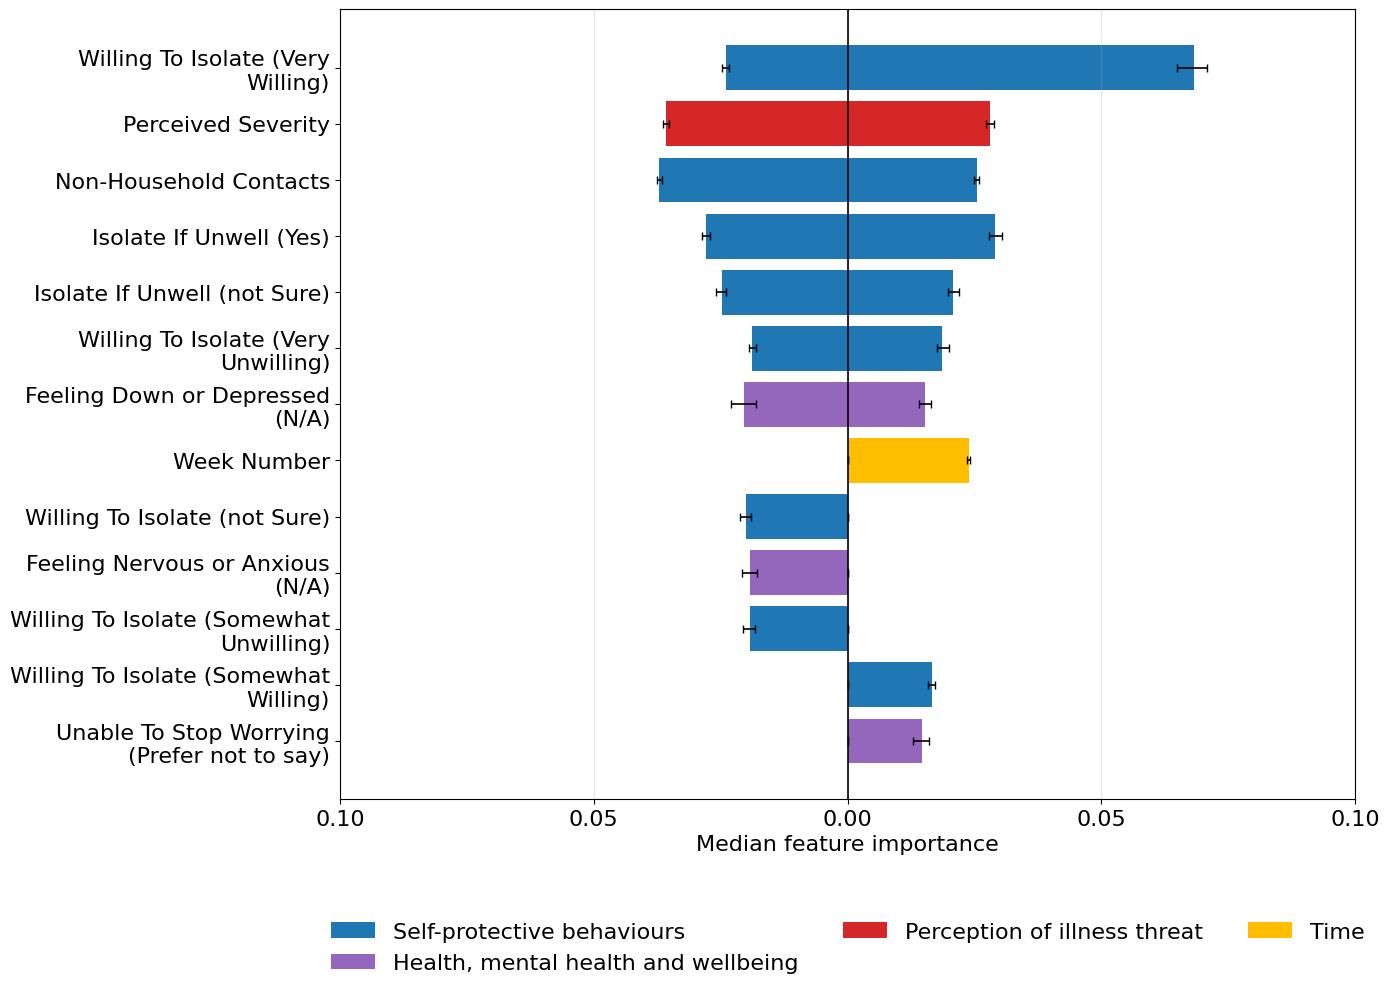

In [24]:
# Remove state variables for final visualisation
importance_2a_no_state = remove_state_features(importance_2a)
importance_2b_no_state = remove_state_features(importance_2b)

# Print top 10 features after removing state variables
print_top_features(
    importance_df=importance_2a_no_state,
    title="Model 2a top 10 features without state variables",
    top_n=top_n
)

print_top_features(
    importance_df=importance_2b_no_state,
    title="Model 2b top 10 features without state variables",
    top_n=top_n
)

# Prepare before-after comparison using non-state features
plot_df_2 = prepare_before_after_df(
    before_df=importance_2a_no_state,
    after_df=importance_2b_no_state,
    top_n_each=top_n
)

plot_df_2.to_csv(
    f"{output_dir}/xgb_model2_feature_importance_readable.csv",
    index=False
)

plot_before_after(
    plot_df=plot_df_2,
    save_path=f"{output_dir}/xgb_model2_before_after.png"
)